In [1]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Dataset

Dataset used for this trial run consisted of ONLY English queries, responses, and sources. Removing non-English sources usually reduces the dataset by half. As a results, we only have the following number of queries/rows:

In [2]:
csv_filename = "./ProcessedDatasets/english_only_responses.csv"
mint_df = pd.read_csv(csv_filename)
print(f"Dataset consisted of {mint_df.shape[0]} queries.")

Dataset consisted of 281 queries.


See process_dataset.py for the comprehensive list of pre-processing done. At a high-level, the following was done:

- Remove rows with Japanese and Korean ASCII characters in query, response, and/or source.
- Remove rows with empty `query` or `response` or `source` entries.
- Remove rows with one or fewer English words in the `query`
   - Single word queries are assumed to be a mistake (accidental queries caused by pressing `Enter` for a search result).
   - We also ignore single word queries because that wouldn't make a good prompt. 

## Evaluation results

The following comes from using an LLM to judge Mitlify's agent. We used the following parameters:

```python
provider="anthropic",
model_name="claude-sonnet-4-5-20250929",
temperature=0,
system_template=SYSTEM_TEMPLATE,
user_template=USER_TEMPLATE,
max_tokens=500,
max_retries=3
```

See Rubric for the judge criteria. I.e. How the judge should rate the responses.

In [3]:
results_df = pd.read_csv("evaluation_results.csv")

### Percent correct

The following calculates percentage of scores (`3`,`2`,`1`). 

> You can also use answer_correct column to count the number of responses that were given a score of 3.

In [45]:
print("Percent of 2 and 3 scores:")
(results_df[results_df['score'] == 2].shape[0] + results_df[results_df['score'] == 3].shape[0])/results_df.shape[0]

Percent of 2 and 3 scores:


0.7473309608540926

In [5]:
score_percent_3 =  (results_df[results_df['score'] == 3].shape[0] / results_df.shape[0]) * 100
score_percent_2 =  (results_df[results_df['score'] == 2].shape[0] / results_df.shape[0]) * 100
score_percent_1 =  (results_df[results_df['score'] == 1].shape[0] / results_df.shape[0]) * 100

Visualizing as a pie chart:

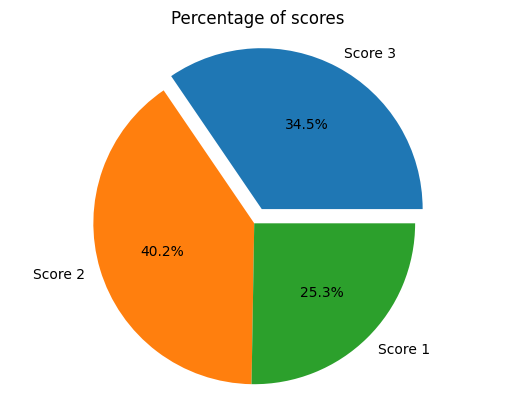

In [6]:
import matplotlib.pyplot as plt
labels = ["Score 3", "Score 2", "Score 1"]
sizes = [score_percent_3, score_percent_2, score_percent_1]

# Create the pie chart
plt.pie(sizes, labels=labels, explode=(0.1, 0, 0),
        autopct='%1.1f%%')

# Ensure the pie chart is drawn as a circle
plt.axis('equal')

# Add a title (optional)
plt.title('Percentage of scores')

# Display the chart
plt.show()

### Deeper dive into responses

To do this, let's first merge our datasets so we can see the query that was asked.

In [44]:
# Concatenate horizontally (axis=1)
combined_df = pd.concat([mint_df, results_df], axis=1)
combined_df.head()

,timestamp,query,response,sources,reason,score,decision,answer_correct,has_error,error_message
0,2025-10-30T19:30:14.008Z,any multi-turn evaluation features on weave,Yes! Weave has multi-turn evaluation features....,"[{""title"":""Evaluate models with W&B Weave and ...",The generated answer makes specific claims abo...,1.0,incorrect,False,False,NaN
1,2025-10-30T19:30:14.008Z,how about simulations?,"Yes, Weave has multi-turn evaluation features!...","[{""title"":""Evaluate models with W&B Weave and ...","The user query ""how about simulations?"" is ext...",1.0,incorrect,False,False,NaN
2,2025-10-30T19:30:14.008Z,cani label a prompt,"Based on my search results, I can answer your ...","[{""title"":""Evaluate models with W&B Weave and ...","The user asked a simple question ""can i label ...",2.0,incorrect,False,False,NaN
3,2025-10-30T17:39:54.553Z,I want to log artifacts for specific runs. E.g...,You can log multiple datatables as artifacts f...,"[{""title"":""WandbEvalCallback"",""url"":""ko/models...",The generated answer addresses logging tables ...,2.0,incorrect,False,False,NaN
4,2025-10-30T17:39:54.553Z,no. lets assume they are artifacts. I want to ...,"Yes, you can log multiple artifacts for a give...","[{""title"":""Tutorial: Create, track, and use a ...",The generated answer correctly addresses the u...,3.0,correct,True,False,NaN


In [9]:
combined_df.columns

Index(['timestamp', 'query', 'response', 'sources', 'reason', 'score',
       'decision', 'answer_correct', 'has_error', 'error_message'],
      dtype='object')

Let's count the lenght of each query and add the results as a new column.

In [10]:
combined_df['query_length'] = combined_df['query'].str.split().str.len()

Let's compute quartiles so we get rid of quartiles

### QR (Interquartile Range) Method
We calculate Q1, Q3, and define any points beyond 1.5 × IQR as outliers.

In [11]:
Q1 = combined_df['query_length'].quantile(0.25)
Q3 = combined_df['query_length'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

filtered_df = combined_df[(combined_df['query_length'] >= lower_bound) & (combined_df['query_length'] <= upper_bound)]

In [12]:
combined_df.head()

,timestamp,query,response,sources,reason,score,decision,answer_correct,has_error,error_message,query_length
0,2025-10-30T19:30:14.008Z,any multi-turn evaluation features on weave,Yes! Weave has multi-turn evaluation features....,"[{""title"":""Evaluate models with W&B Weave and ...",The generated answer makes specific claims abo...,1.0,incorrect,False,False,NaN,6
1,2025-10-30T19:30:14.008Z,how about simulations?,"Yes, Weave has multi-turn evaluation features!...","[{""title"":""Evaluate models with W&B Weave and ...","The user query ""how about simulations?"" is ext...",1.0,incorrect,False,False,NaN,3
2,2025-10-30T19:30:14.008Z,cani label a prompt,"Based on my search results, I can answer your ...","[{""title"":""Evaluate models with W&B Weave and ...","The user asked a simple question ""can i label ...",2.0,incorrect,False,False,NaN,4
3,2025-10-30T17:39:54.553Z,I want to log artifacts for specific runs. E.g...,You can log multiple datatables as artifacts f...,"[{""title"":""WandbEvalCallback"",""url"":""ko/models...",The generated answer addresses logging tables ...,2.0,incorrect,False,False,NaN,24
4,2025-10-30T17:39:54.553Z,no. lets assume they are artifacts. I want to ...,"Yes, you can log multiple artifacts for a give...","[{""title"":""Tutorial: Create, track, and use a ...",The generated answer correctly addresses the u...,3.0,correct,True,False,NaN,16


#### Histogram / KDE of Query Length per Score

Purpose: See how the distribution of query lengths differs for each score.

Insight Goal: Are high scores associated with longer or shorter queries? Are the distributions overlapping or distinct?

Text(0, 0.5, 'Frequency')

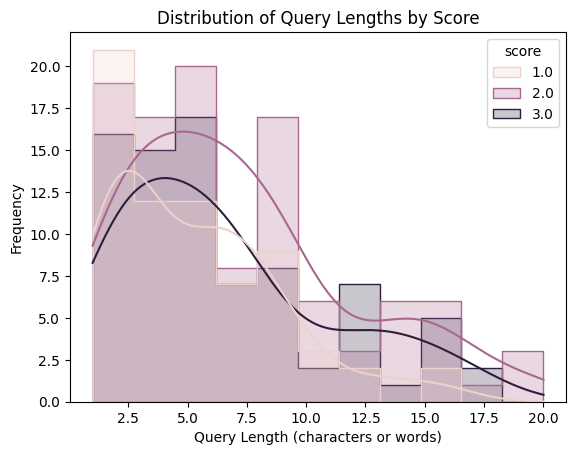

In [13]:
sns.histplot(data=filtered_df, x='query_length', hue='score', kde=True, element='step', common_norm=False)
plt.title("Distribution of Query Lengths by Score")
plt.xlabel("Query Length (characters or words)")
plt.ylabel("Frequency")

Density curve equivalent

Text(0, 0.5, 'Frequency')

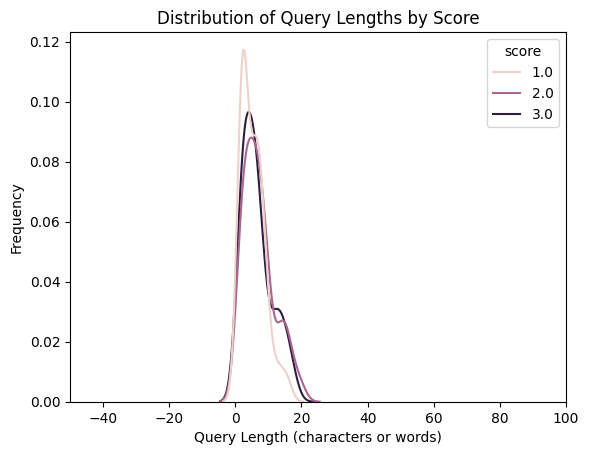

In [14]:
sns.kdeplot(data=filtered_df, x='query_length', hue='score', common_norm=False)
plt.title("Distribution of Query Lengths by Score")
plt.xlabel("Query Length (characters or words)")
plt.xlim((-50, 100))
plt.ylabel("Frequency")

#### Boxplot or Violin Plot of Query Length vs. Score

Purpose: Compare central tendency and variability.

Insight goal: Does query length increase or decrease with score? Is there more variance in one score group?

Text(0.5, 1.0, 'Query Length Distribution by Score')

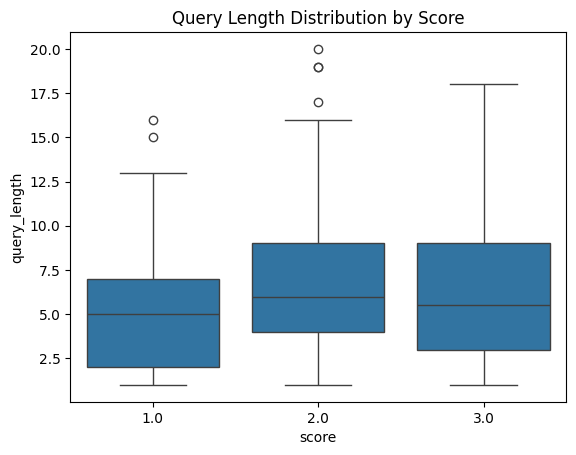

In [15]:
sns.boxplot(data=filtered_df, x='score', y='query_length')
plt.title("Query Length Distribution by Score")

<Axes: xlabel='score', ylabel='query_length'>

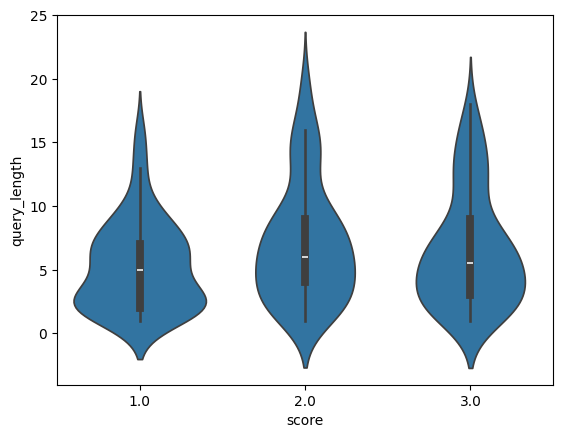

In [16]:
sns.violinplot(data=filtered_df, x='score', y='query_length')

#### Scatter Plot with Jitter
Purpose: Directly visualize the relationship between query length and score.

Text(0.5, 1.0, 'Query Length vs Score (Scatter)')

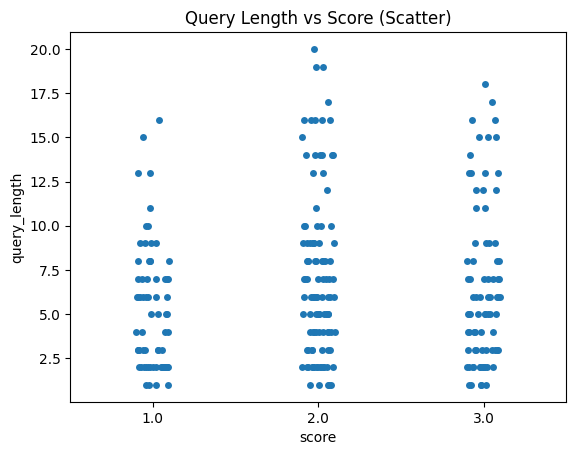

In [17]:
sns.stripplot(data=filtered_df, x='score', y='query_length', jitter=True)
plt.title("Query Length vs Score (Scatter)")

#### Bar Plot of Mean Query Length by Score (with Error Bars)
Purpose: Simple summary statistic comparison.

Insight Goal: Are mean query lengths increasing or decreasing as score increases?
Does variance differ significantly?

/var/folders/8l/17pbmxnj7l58_psygsk0dpzw0000gn/T/ipykernel_57162/2623282392.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=filtered_df, x='score', y='query_length', ci='sd')


Text(0.5, 1.0, 'Average Query Length by Score')

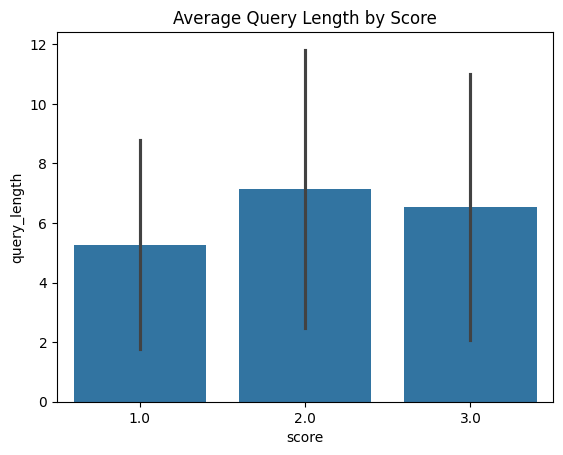

In [18]:
sns.barplot(data=filtered_df, x='score', y='query_length', ci='sd')
plt.title("Average Query Length by Score")

#### Boxen Plot (Deep Distribution Insight)

For large datasets, this is more informative than a boxplot.

<Axes: xlabel='score', ylabel='query_length'>

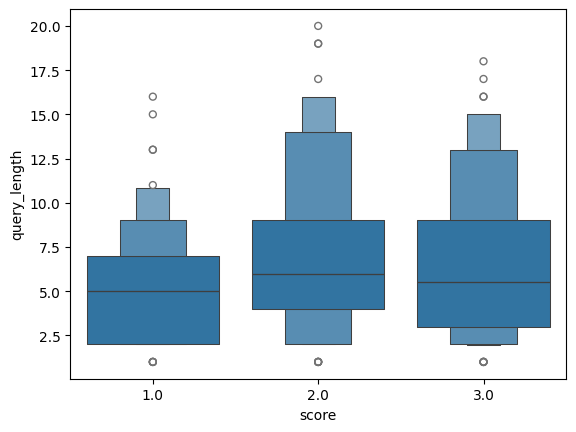

In [19]:
sns.boxenplot(data=filtered_df, x='score', y='query_length')

#### Correlation heatmap
If you compute multiple text-derived metrics (e.g. query length, word count, punctuation count), you can see which correlate most strongly with score.

Text(0.5, 1.0, 'Correlation between Query Length and Score')

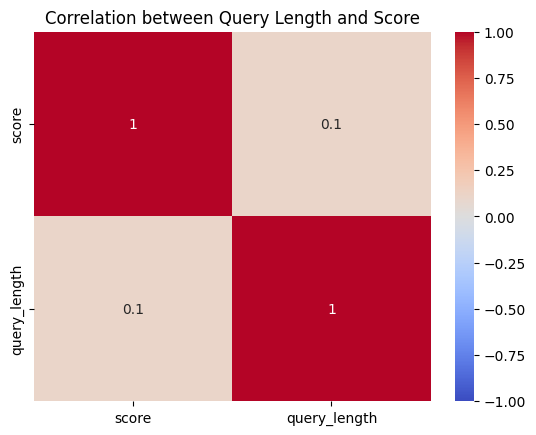

In [20]:
corr = filtered_df[['score', 'query_length']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation between Query Length and Score")

#### Diagnostic & Contextual Plots (Optional)

If your dataset also contains fields like has_error or answer_correct, you can stratify by those variables to reveal confounding effects.

Text(0.5, 1.0, 'Query Length vs Score, Split by Answer Correctness')

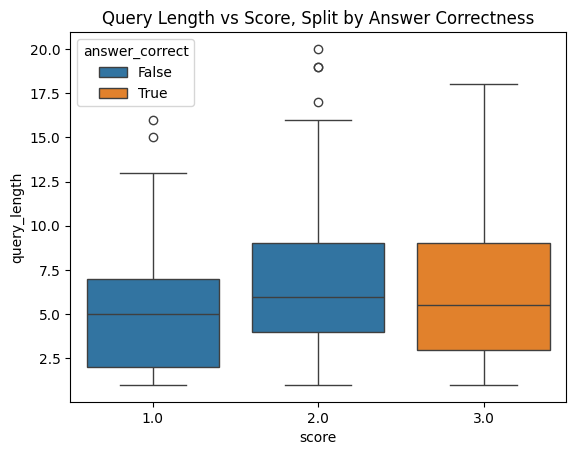

In [21]:
sns.boxplot(data=filtered_df, x='score', y='query_length', hue='answer_correct')
plt.title("Query Length vs Score, Split by Answer Correctness")

---

## Investigating wrong answers

Are there any words that are commonlyy found in queries or sources?

In [23]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk import FreqDist
from collections import Counter
import warnings

warnings.filterwarnings("ignore")

def preprocess(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation and numbers
    text = re.sub(r"[^a-z\s]", "", text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]
    return tokens

In [24]:
nltk.download('stopwords')
nltk.download('punkt_tab')
stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/noahluna/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/noahluna/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [25]:
def calculate_word_distribution(series: pd.Series, column_name: str, most_common: int):
    # Flatten all tokens into one list
    all_tokens = [token for tokens in series[column_name] for token in tokens]

    # Count words
    word_counts = Counter(all_tokens)

    fdist = FreqDist(all_tokens)
    fdist.most_common(most_common)
    return fdist

def plot_word_distribution(fdist: nltk.probability.FreqDist, samples: int, title: str, filename: str = None):
    fdist.plot(samples, cumulative=False)
    plt.title(title)
    if filename:
        plt.savefig(filename, bbox_inches='tight')
    plt.show()

The following are common variables for all plots:

In [26]:
common_word_num = 10 # Find the N most common words
samples = 20 # x-axis for plot

----

### Score 1

In [27]:
# Create pandas Series object that consists only of score 1 (i.e. wrong)
score_one_series = filtered_df[filtered_df['score'] == 1.0]

#### Distribution of words - Query

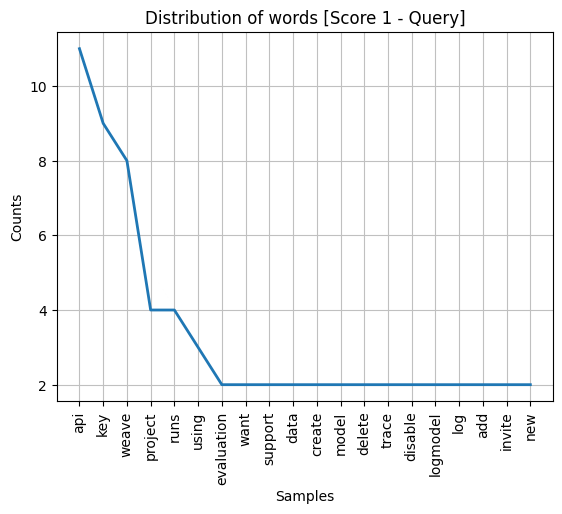

In [28]:
# Column to grab from Pandas Series
column = "query"
# New column with filtered results
query_tokens_column_name = "query_tokens"

# Title for the plot
title = "Distribution of words [Score 1 - Query]"
# .png filename
plot_filename = "score_one_query_distribution"

# Apply preprocessing
score_one_series[query_tokens_column_name] = score_one_series[column].apply(preprocess)

# Calculate most common words
most_common_words = calculate_word_distribution(score_one_series, query_tokens_column_name, common_word_num)

# Plot the distribution
plot_word_distribution(most_common_words, samples, title, plot_filename)

#### Distribution of words - Sources

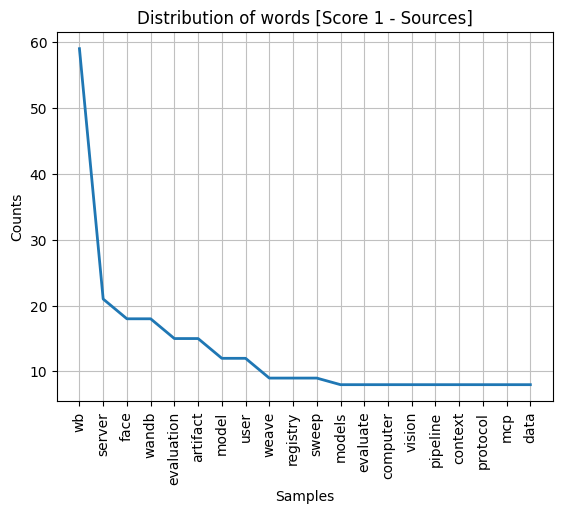

In [29]:
# Column to grab from Pandas Series
column = "sources"
# New column with filtered results
query_tokens_column_name = "sources_tokens"

# Plot title
title = "Distribution of words [Score 1 - Sources]"
# .png filename
filename = "score_one_source_distribution"

# Apply preprocessing to the column, add it as a new column
score_one_series[query_tokens_column_name] = score_one_series[column].apply(preprocess)

# Calculate most common words
most_common_words = calculate_word_distribution(score_one_series, query_tokens_column_name, common_word_num)

# Plot the distribution
plot_word_distribution(most_common_words, samples, title, filename)

### Score 2
Create a Pandas Series that consists of only rows that posses score == 2.0

In [30]:
# Create pandas Series object that consists only of score 2 (i.e. sort of correct)
score_two_series = filtered_df[filtered_df['score'] == 2.0]

#### Distribution of words - Queries

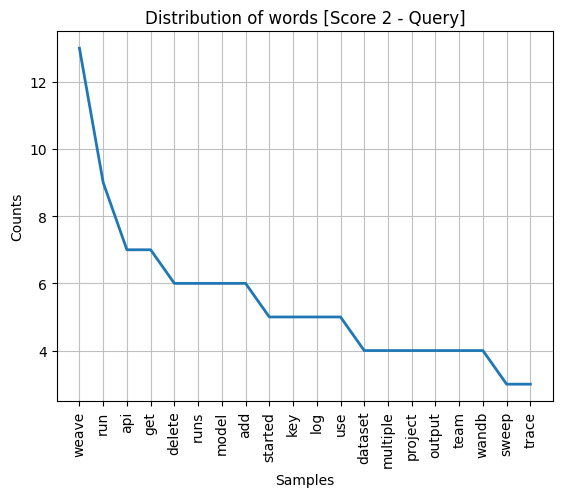

In [31]:
# Column to grab from Pandas Series
column = "query"
# New column with filtered results
query_tokens_column_name = "query_tokens"

# Plot title
title = "Distribution of words [Score 2 - Query]"
# .png filename
filename = "score_two_query_distribution"

# Apply preprocessing to the column, add it as a new column
score_two_series[query_tokens_column_name] = score_two_series[column].apply(preprocess)

# Calculate most common words
most_common_words = calculate_word_distribution(score_two_series, query_tokens_column_name, common_word_num)

# Plot the distribution
plot_word_distribution(most_common_words, samples, title, filename)

#### Distribution of words - Sources

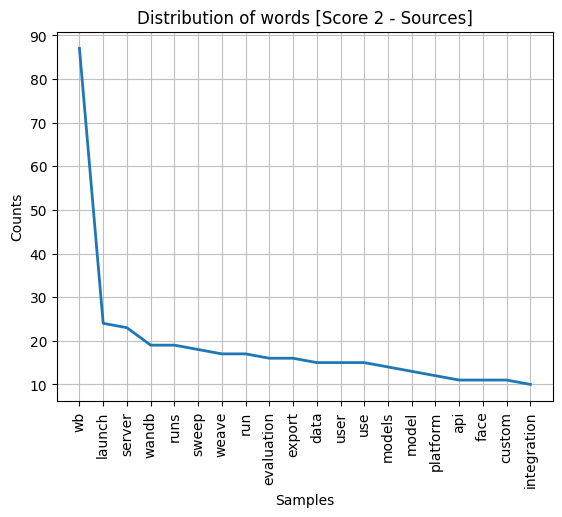

In [32]:
# Column to grab from Pandas Series
column = "sources"
# New column with filtered results
query_tokens_column_name = "sources_tokens"

# Title for the plot
title = "Distribution of words [Score 2 - Sources]"
# .png filename
filename = "score_two_source_distribution"

# Apply preprocessing to the column, add it as a new column
score_two_series[query_tokens_column_name] = score_two_series[column].apply(preprocess)

# Calculate most common words
most_common_words = calculate_word_distribution(score_two_series, query_tokens_column_name, common_word_num)

# Plot the distribution
plot_word_distribution(most_common_words, samples, title, filename)

## Distributions of most commonly refernced URLs by agent

The following looks at the most commonly references URLs in ALL sources. (i.e. Does not look at those who had a score of 1, 2, or 3).

In [33]:
def get_urls(series: pd.Series):
    """Get URLs from `source` column."""
    all_urls = []
    for entry in series["sources"].dropna():
        try:
            items = json.loads(entry)
            for item in items:
                url = item.get("url")
                if url:
                    all_urls.append(url)
        except json.JSONDecodeError:
            # Skip malformed JSON
            continue
    return all_urls

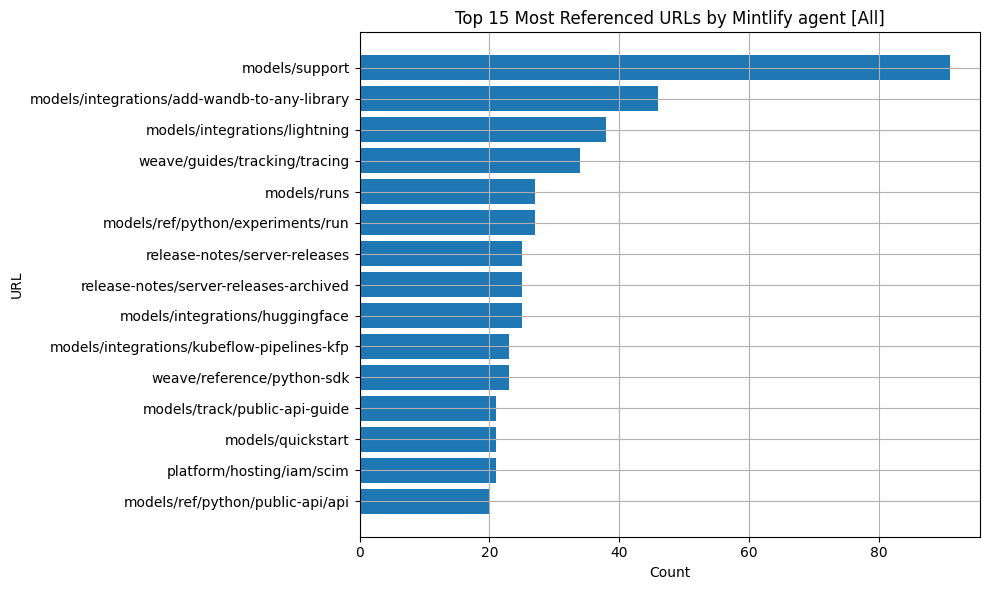

In [40]:
# Get URLs
all_urls = get_urls(filtered_df)

# Count the frequency of each URL
url_counts = Counter(all_urls)

# Convert to a DataFrame for further analysis or plotting
url_df = pd.DataFrame(url_counts.items(), columns=["url", "count"])
url_df = url_df.sort_values(by="count", ascending=False).reset_index(drop=True)

# Plot the distribution
top_n = 15
plt.figure(figsize=(10, 6))
plt.barh(url_df["url"].head(top_n)[::-1], url_df["count"].head(top_n)[::-1])
plt.xlabel("Count")
plt.ylabel("URL")
plt.title(f"Top {top_n} Most Referenced URLs by Mintlify agent [All]")
plt.tight_layout()
plt.grid(True)
plt.savefig("url_references_all" , bbox_inches = "tight")
plt.show()

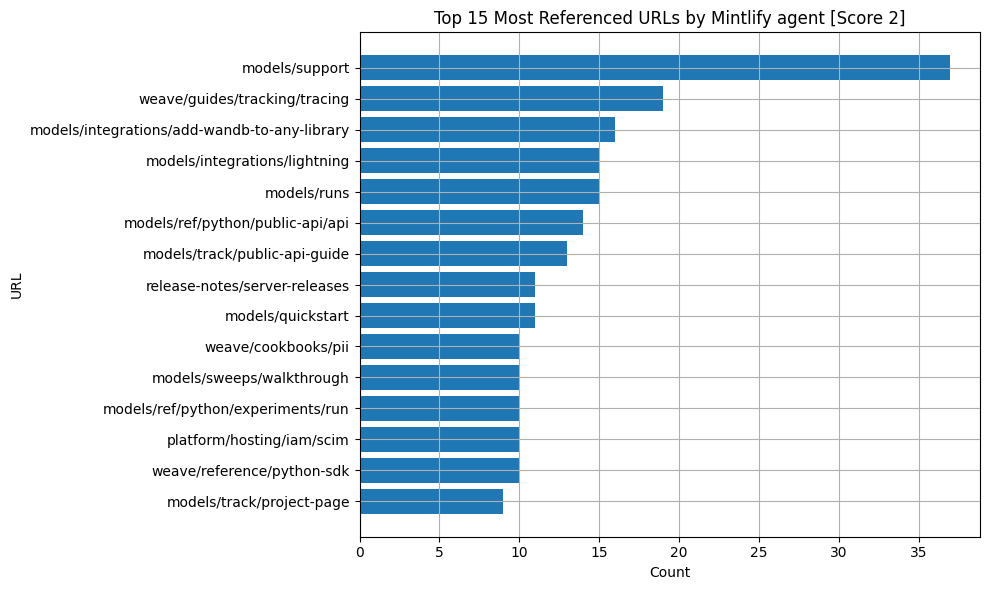

In [41]:
# Get URLs
all_urls = get_urls(score_two_series)

# Count the frequency of each URL
url_counts = Counter(all_urls)

# Convert to a DataFrame for further analysis or plotting
url_df = pd.DataFrame(url_counts.items(), columns=["url", "count"])
url_df = url_df.sort_values(by="count", ascending=False).reset_index(drop=True)

# Plot the distribution
top_n = 15
plt.figure(figsize=(10, 6))
plt.barh(url_df["url"].head(top_n)[::-1], url_df["count"].head(top_n)[::-1])
plt.xlabel("Count")
plt.ylabel("URL")
plt.title(f"Top {top_n} Most Referenced URLs by Mintlify agent [Score 2]")
plt.tight_layout()
plt.grid(True)
plt.savefig("url_references_score_two" , bbox_inches = "tight")
plt.show()

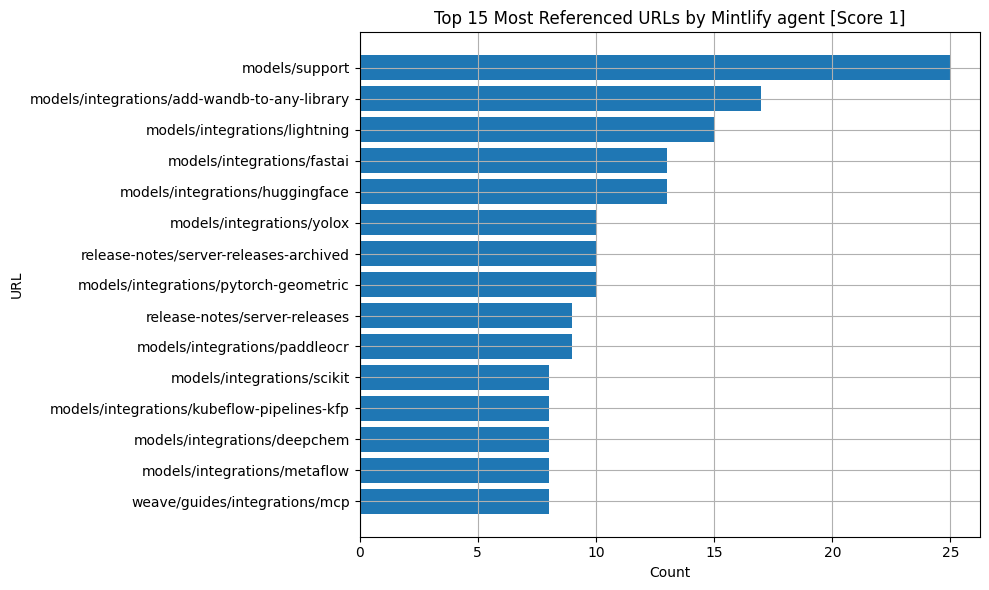

In [42]:
# Get URLs
all_urls = get_urls(score_one_series)

# Count the frequency of each URL
url_counts = Counter(all_urls)

# Convert to a DataFrame for further analysis or plotting
url_df = pd.DataFrame(url_counts.items(), columns=["url", "count"])
url_df = url_df.sort_values(by="count", ascending=False).reset_index(drop=True)

# Plot the distribution
top_n = 15
plt.figure(figsize=(10, 6))
plt.barh(url_df["url"].head(top_n)[::-1], url_df["count"].head(top_n)[::-1])
plt.xlabel("Count")
plt.ylabel("URL")
plt.title(f"Top {top_n} Most Referenced URLs by Mintlify agent [Score 1]")
plt.tight_layout()
plt.grid(True)
plt.savefig("url_references_score_one" , bbox_inches = "tight")
plt.show()

## Future questions

- Does the agent do better or worse on Weave or Models docs?
- Within Models, how does it perform with Python SDK or CLI docs?